In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
ipl = pd.read_csv("ipl_cleaned_data.csv")

/tmp/ipython-input-2320493293.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  ipl = pd.read_csv("ipl_cleaned_data.csv")


In [33]:
ipl.head()

,matchid,inning,over,ball,batting_team,bowling_team,batsman,bowler,batsman_runs,extras,total_runs,iswide,isnoball,player_dismissed,season,date,venue,team1,team2,winner
0,335982,1,0,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,0,1,1,0.0,0.0,Not Out,2007/08,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,335982,1,0,2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0,0,0.0,0.0,Not Out,2007/08,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
2,335982,1,0,3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,1,1,1.0,0.0,Not Out,2007/08,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
3,335982,1,0,4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0,0,0.0,0.0,Not Out,2007/08,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
4,335982,1,0,5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0,0,0.0,0.0,Not Out,2007/08,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders


In [34]:
ipl.shape
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260917 entries, 0 to 260916
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   matchid           260917 non-null  int64  
 1   inning            260917 non-null  int64  
 2   over              260917 non-null  int64  
 3   ball              260917 non-null  int64  
 4   batting_team      260917 non-null  object 
 5   bowling_team      260917 non-null  object 
 6   batsman           260917 non-null  object 
 7   bowler            260917 non-null  object 
 8   batsman_runs      260917 non-null  int64  
 9   extras            260917 non-null  int64  
 10  total_runs        260917 non-null  int64  
 11  iswide            260917 non-null  float64
 12  isnoball          260917 non-null  float64
 13  player_dismissed  260917 non-null  object 
 14  season            260917 non-null  object 
 15  date              260917 non-null  object 
 16  venue             26

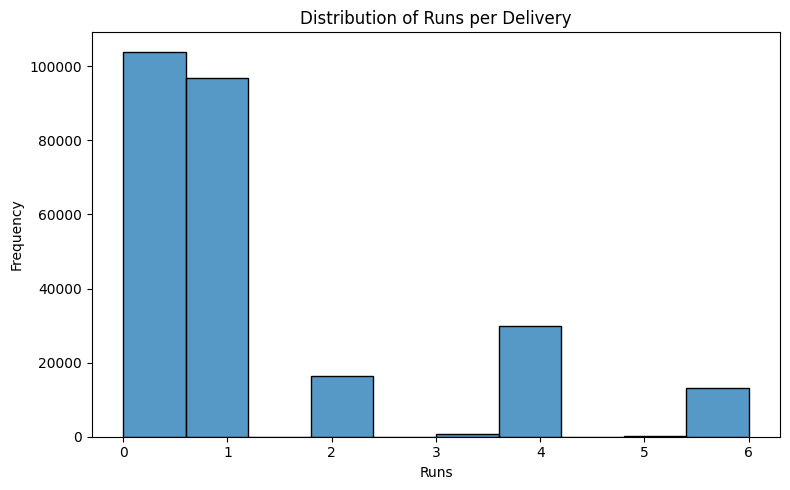

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(ipl["batsman_runs"], bins=10)
plt.title("Distribution of Runs per Delivery")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

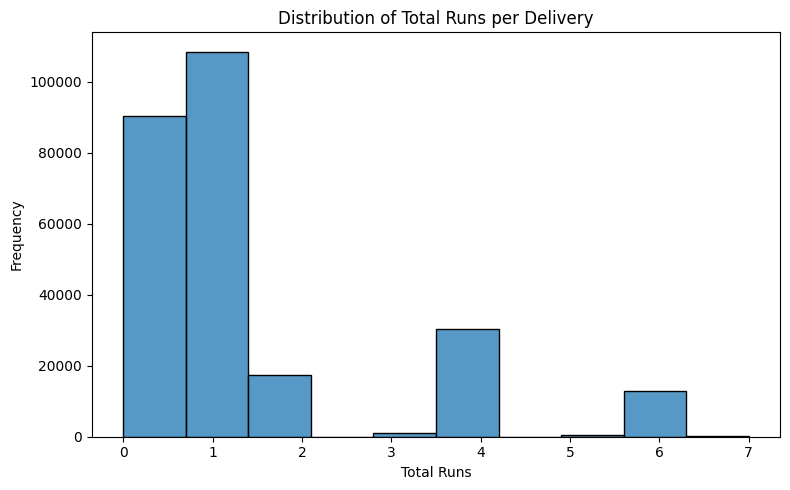

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(ipl["total_runs"], bins=10)
plt.title("Distribution of Total Runs per Delivery")
plt.xlabel("Total Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

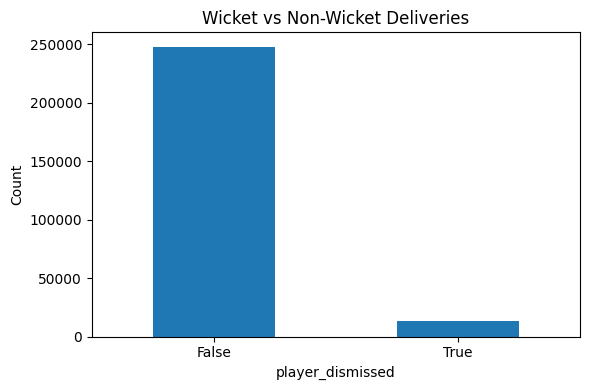

In [37]:
wickets = ipl["player_dismissed"] != "Not Out"
plt.figure(figsize=(6,4))
wickets.value_counts().plot(kind="bar")
plt.title("Wicket vs Non-Wicket Deliveries")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
runs_per_over = (
    ipl.groupby(["matchid", "inning", "over"])["total_runs"]
    .sum()
    .reset_index()
)

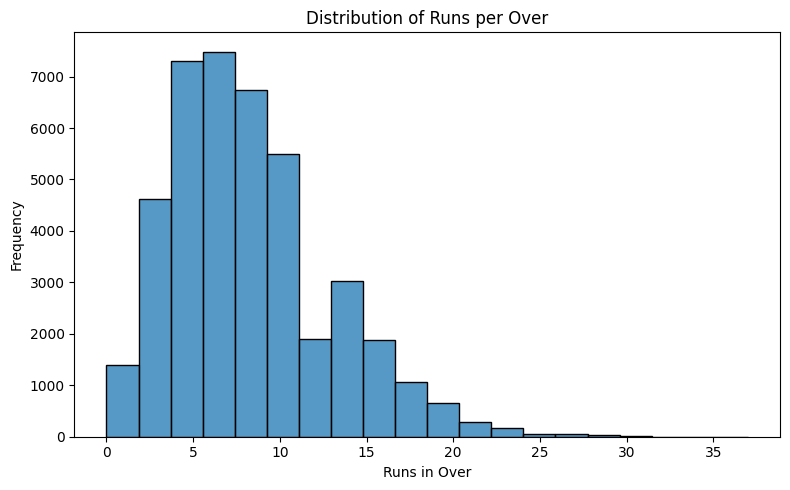

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(runs_per_over["total_runs"], bins=20)
plt.title("Distribution of Runs per Over")
plt.xlabel("Runs in Over")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [40]:
venue_runs = (
    ipl.groupby(["matchid", "venue"])["total_runs"]
    .sum()
    .reset_index()
)

venue_avg = (
    venue_runs.groupby("venue")["total_runs"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

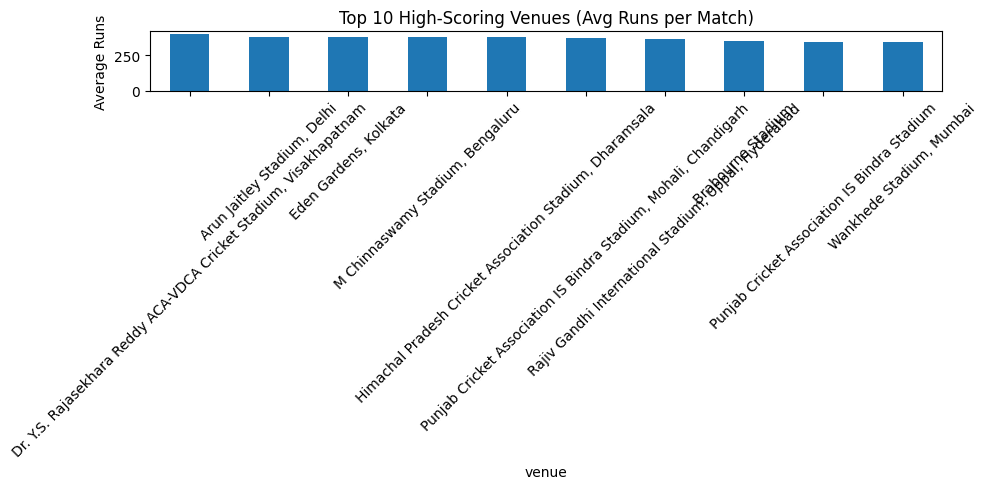

In [41]:
plt.figure(figsize=(10,5))
venue_avg.plot(kind="bar")
plt.title("Top 10 High-Scoring Venues (Avg Runs per Match)")
plt.ylabel("Average Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
team_runs = (
    ipl.groupby("batting_team")["total_runs"]
    .sum()
    .sort_values(ascending=False)
)

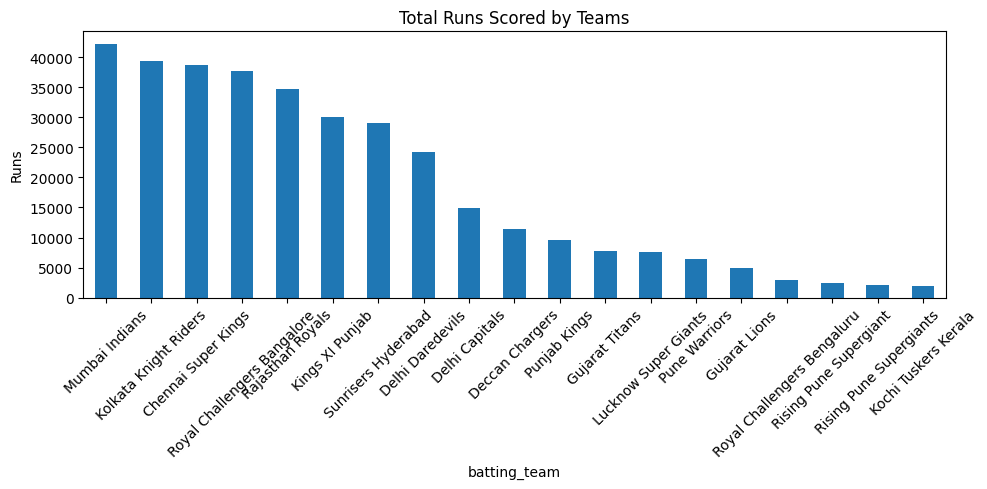

In [43]:
plt.figure(figsize=(10,5))
team_runs.plot(kind="bar")
plt.title("Total Runs Scored by Teams")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
numeric_cols = ipl[["batsman_runs", "extras", "total_runs"]]
numeric_cols.corr()

,batsman_runs,extras,total_runs
batsman_runs,1.000000,-0.142080,0.977934
extras,-0.142080,1.000000,0.067851
total_runs,0.977934,0.067851,1.000000


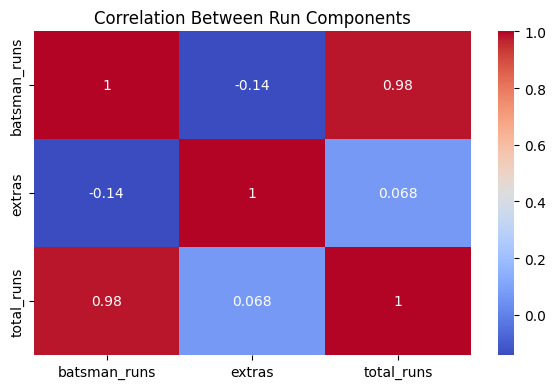

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Run Components")
plt.tight_layout()
plt.show()